# Process bulk counts table

1. Annotate columns (samples) in a way that time point and replicate are annotated
2. Remove rRNA genes
3. Perform TPM normalization and alternatively also raw counts

In [38]:
# Use miniconda environment Jupyter_new for running this notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from tools import *
import warnings
warnings.filterwarnings('ignore')

## 1 Load the dataset and annotation

In [39]:
bulkPath = '../nf_output/countData/countData.tsv' 
metaPath = '../SraRunTable.csv' # metadata from SRA
gffPath = '../nf_output/alignments/dualGenome.gff3' # output from nf pipeline

In [40]:
# Load data
df_initial = pd.read_csv(bulkPath, sep = '\t', comment='#', index_col=0)
metadata = pd.read_csv(metaPath)

In [41]:
df_initial

,Chr,Start,End,Strand,Length,SRR12281651_sorted.bam,SRR12281653_sorted.bam,SRR12281648_sorted.bam,SRR12281650_sorted.bam,SRR12281652_sorted.bam,SRR12281646_sorted.bam,SRR12281644_sorted.bam,SRR12281647_sorted.bam,SRR12281649_sorted.bam,SRR12281645_sorted.bam
Geneid,,,,,,,,,,,,,,,
gene-HB27c_C0001,CP053287.1,74,1171,-,1098,6,4,6,4,11,4,1,5,10,5
gene-HB27c_C0002,CP053287.1,1281,2051,+,771,43,52,53,38,76,34,23,37,86,40
gene-HB27c_C0003,CP053287.1,2097,2639,-,543,87,106,114,100,156,82,67,113,160,95
gene-HB27c_C0004,CP053287.1,3280,3362,-,83,2,9,9,2,9,1,3,4,5,3
gene-HB27c_C0005,CP053287.1,3982,4311,+,330,15,26,16,10,39,9,5,13,19,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
gene-phiKo_05,MH673671.2,8786,9343,+,558,7,1,40,9,1,1643,8216,2299,69,11089
gene-phiKo_04,MH673671.2,9340,9771,+,432,3,2,131,13,1,4449,12833,5038,132,17088
gene-phiKo_03,MH673671.2,9768,10577,+,810,7,1,157,12,3,6534,20811,7999,178,27386


In [42]:
metadata

,Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,BioSampleModel,Bytes,Center Name,Consent,...,Sample Name,SRA Study,lab_host,sample_type,strain,Host,isolate,isolation_source,Collection_Date,Note
0,SRR11746543,WGS,2862,185717744,PRJNA631468,SAMN14864047,"Microbe\, viral or environmental",167418976,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,"Thermus thermophilus HB27c DNA, complete genome",SRP260977,NaN,overnight culture obtained from a single clone,HB27c,NaN,NaN,missing,NaN,model laboratory strain
1,SRR11746544,WGS,502,317950736,PRJNA631468,SAMN14864047,"Microbe\, viral or environmental",215885134,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,"Thermus thermophilus HB27c DNA, complete genome",SRP260977,NaN,overnight culture obtained from a single clone,HB27c,NaN,NaN,missing,NaN,model laboratory strain
2,SRR11824631,WGS,150,30454650,PRJNA631468,SAMN14983641,Viral,12382260,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,phiFa_ORF42escapers_monoisolates,SRP260977,T. thermophilus HB27c,NaN,NaN,T. thermophilus,monoisolate,culture of T. thermophilus HB27c with a spacer...,2019.0,NaN
3,SRR11824632,WGS,150,39904950,PRJNA631468,SAMN14983641,Viral,16314690,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,phiFa_ORF42escapers_monoisolates,SRP260977,T. thermophilus HB27c,NaN,NaN,T. thermophilus,monoisolate,culture of T. thermophilus HB27c with a spacer...,2019.0,NaN
4,SRR11824633,WGS,150,8605650,PRJNA631468,SAMN14983640,Viral,3409710,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,phiFa_ORF44escapers_monoisolates,SRP260977,T. thermophilus HB27c,NaN,NaN,T. thermophilus,monoisolate,culture of T. thermophilus HB27c with a spacer...,2019.0,NaN
5,SRR11824634,WGS,150,56166000,PRJNA631468,SAMN14983640,Viral,22260159,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,phiFa_ORF44escapers_monoisolates,SRP260977,T. thermophilus HB27c,NaN,NaN,T. thermophilus,monoisolate,culture of T. thermophilus HB27c with a spacer...,2019.0,NaN
6,SRR11824635,WGS,150,60374550,PRJNA631468,SAMN14983639,Viral,25648345,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,phiFa_WT(control),SRP260977,T. thermophilus HB27c,NaN,NaN,T. thermophilus,monoisolate,NaN,NaN,NaN
7,SRR11818503,AMPLICON,302,203660646,PRJNA631468,SAMN14973004,Viral,84468123,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,phiFa_ORF42_escapers,SRP260977,T. thermophilus HB27c Fa_E42,NaN,NaN,T. thermophilus,multi isolate,NaN,NaN,NaN
8,SRR11818504,AMPLICON,302,280164494,PRJNA631468,SAMN14973003,Viral,111186028,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,phiFa_ORF44_ecsapers,SRP260977,T. thermophilus HB27c Fa_E44,NaN,NaN,T. thermophilus,multi isolate,NaN,NaN,NaN
9,SRR11818505,AMPLICON,302,301336506,PRJNA631468,SAMN14970653,"Microbe\, viral or environmental",134325663,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,Thermus thermophilus HB27c infected with phiFa...,SRP260977,NaN,bacterial culture infected with a phage,HB27c,NaN,NaN,NaN,NaN,NaN


In [43]:
metadata = metadata.loc[metadata['Assay Type'] == 'RNA-Seq']
metadata

,Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,BioSampleModel,Bytes,Center Name,Consent,...,Sample Name,SRA Study,lab_host,sample_type,strain,Host,isolate,isolation_source,Collection_Date,Note
17,SRR12281644,RNA-Seq,55,285295725,PRJNA631468,SAMN15569106,Viral,108828705,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,T. thermophilus HB27c infected with phiKo phag...,SRP260977,Thermus thermophilus HB27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,SRR12281645,RNA-Seq,55,342820170,PRJNA631468,SAMN15569106,Viral,130163540,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,T. thermophilus HB27c infected with phiKo phag...,SRP260977,Thermus thermophilus HB27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,SRR12281646,RNA-Seq,55,272552610,PRJNA631468,SAMN15569106,Viral,104098158,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,T. thermophilus HB27c infected with phiKo phag...,SRP260977,Thermus thermophilus HB27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,SRR12281647,RNA-Seq,55,287005235,PRJNA631468,SAMN15569106,Viral,110112795,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,T. thermophilus HB27c infected with phiKo phag...,SRP260977,Thermus thermophilus HB27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,SRR12281648,RNA-Seq,55,245335640,PRJNA631468,SAMN15569106,Viral,94451099,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,T. thermophilus HB27c infected with phiKo phag...,SRP260977,Thermus thermophilus HB27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,SRR12281649,RNA-Seq,55,293872975,PRJNA631468,SAMN15569106,Viral,112225547,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,T. thermophilus HB27c infected with phiKo phag...,SRP260977,Thermus thermophilus HB27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,SRR12281650,RNA-Seq,55,253991485,PRJNA631468,SAMN15569106,Viral,97570242,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,T. thermophilus HB27c infected with phiKo phag...,SRP260977,Thermus thermophilus HB27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,SRR12281651,RNA-Seq,55,231521510,PRJNA631468,SAMN15569106,Viral,89203271,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,T. thermophilus HB27c infected with phiKo phag...,SRP260977,Thermus thermophilus HB27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,SRR12281652,RNA-Seq,55,262801385,PRJNA631468,SAMN15569106,Viral,101252768,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,T. thermophilus HB27c infected with phiKo phag...,SRP260977,Thermus thermophilus HB27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,SRR12281653,RNA-Seq,55,233978910,PRJNA631468,SAMN15569106,Viral,89938429,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,T. thermophilus HB27c infected with phiKo phag...,SRP260977,Thermus thermophilus HB27,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
metadata['Library Name'] # required column for sample name annotation

17    RNA_TTHB27c_phiKo_70min_rep2
18    RNA_TTHB27c_phiKo_70min_rep1
19    RNA_TTHB27c_phiKo_50min_rep2
20    RNA_TTHB27c_phiKo_50min_rep1
21    RNA_TTHB27c_phiKo_30min_rep2
22    RNA_TTHB27c_phiKo_30min_rep1
23    RNA_TTHB27c_phiKo_10min_rep2
24    RNA_TTHB27c_phiKo_10min_rep1
25     RNA_TTHB27c_phiKo_0min_rep2
26     RNA_TTHB27c_phiKo_0min_rep1
Name: Library Name, dtype: object

## 2 Format the dataset

### 2.1 Annotate sample names

Issue now is that the metadata does not properly annotate sample names. Thus, this will be done manually by adding another sample name column to the metadata.

In [45]:
# Match SRR IDs and SampleNames inferred from metadata

sampleInfo = metadata[['Run', 'Library Name']]
sampleInfo['timepoint'] = sampleInfo['Library Name'].str.split('_', expand=True)[3].str[:-3]
sampleInfo['replicate'] = sampleInfo['Library Name'].str.split('_', expand=True)[4].str[3]
sampleInfo['sampleName'] = [f"{sampleInfo.loc[i,'timepoint']}_R{sampleInfo.loc[i,'replicate']}" for i in sampleInfo.index.tolist()]
sampleInfo.index = sampleInfo['Run']
sampleInfo

,Run,Library Name,timepoint,replicate,sampleName
Run,,,,,
SRR12281644,SRR12281644,RNA_TTHB27c_phiKo_70min_rep2,70,2,70_R2
SRR12281645,SRR12281645,RNA_TTHB27c_phiKo_70min_rep1,70,1,70_R1
SRR12281646,SRR12281646,RNA_TTHB27c_phiKo_50min_rep2,50,2,50_R2
SRR12281647,SRR12281647,RNA_TTHB27c_phiKo_50min_rep1,50,1,50_R1
SRR12281648,SRR12281648,RNA_TTHB27c_phiKo_30min_rep2,30,2,30_R2
SRR12281649,SRR12281649,RNA_TTHB27c_phiKo_30min_rep1,30,1,30_R1
SRR12281650,SRR12281650,RNA_TTHB27c_phiKo_10min_rep2,10,2,10_R2
SRR12281651,SRR12281651,RNA_TTHB27c_phiKo_10min_rep1,10,1,10_R1
SRR12281652,SRR12281652,RNA_TTHB27c_phiKo_0min_rep2,0,2,0_R2


In [46]:
sampleDict = sampleInfo['sampleName'].to_dict()
sampleDict

{'SRR12281644': '70_R2',
 'SRR12281645': '70_R1',
 'SRR12281646': '50_R2',
 'SRR12281647': '50_R1',
 'SRR12281648': '30_R2',
 'SRR12281649': '30_R1',
 'SRR12281650': '10_R2',
 'SRR12281651': '10_R1',
 'SRR12281652': '0_R2',
 'SRR12281653': '0_R1'}

In [47]:
metadataFull = annotateData(metadata, sampleDict)

In [48]:
metadataFull.head(1)

,Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,BioSampleModel,Bytes,Center Name,Consent,...,lab_host,sample_type,strain,Host,isolate,isolation_source,Collection_Date,Note,SampleID,SampleNames
SampleID,,,,,,,,,,,,,,,,,,,,,
SRR12281644_sorted.bam,SRR12281644,RNA-Seq,55,285295725,PRJNA631468,SAMN15569106,Viral,108828705,SKOLKOVO INSTITUTE OF SCIENCE AND TECHNOLOGY,public,...,Thermus thermophilus HB27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SRR12281644_sorted.bam,70_R2


Add correct sample names.

In [49]:
df = changeColnames(df_initial.iloc[:,5:df_initial.shape[1]], metadataFull)
df = df[['0_R1', '0_R2', '10_R1', '10_R2', '30_R1', '30_R2', '50_R1', '50_R2', '70_R1', '70_R2']]
df

SampleNames,0_R1,0_R2,10_R1,10_R2,30_R1,30_R2,50_R1,50_R2,70_R1,70_R2
Geneid,,,,,,,,,,
gene-HB27c_C0001,4,11,6,4,10,6,5,4,5,1
gene-HB27c_C0002,52,76,43,38,86,53,37,34,40,23
gene-HB27c_C0003,106,156,87,100,160,114,113,82,95,67
gene-HB27c_C0004,9,9,2,2,5,9,4,1,3,3
gene-HB27c_C0005,26,39,15,10,19,16,13,9,5,5
...,...,...,...,...,...,...,...,...,...,...
gene-phiKo_05,1,1,7,9,69,40,2299,1643,11089,8216
gene-phiKo_04,2,1,3,13,132,131,5038,4449,17088,12833
gene-phiKo_03,1,3,7,12,178,157,7999,6534,27386,20811


### 2.2 Remove rRNA genes

2.1 Process gff3 files for front end processing

In [50]:
# Load gff3 and split into genes and CDS dfs
gff3 = pd.read_csv(gffPath, sep='\t', header = None, comment='#')
gff3.columns=["seq_id", "source", "type", "start", "end", "phase", "strand", "score", "attributes"]
gff3_genes = gff3.loc[gff3["type"] == 'gene']

# Column formating for genes
gff3_genes = gff3_genes.reset_index(drop=True)
dct_genes = gff3_genes["attributes"].str.split(';').apply(lambda items: dict(item.split('=', 1) for item in items if '=' in item))
cols_to_keep = ['ID', 'Name', 'gbkey', 'gene_biotype', 'locus_tag', 'gene']
gff3_genes = pd.concat([gff3_genes, pd.json_normalize(dct_genes)[cols_to_keep]], axis=1)

# Generate locus_tag, product dictonary over all different feature types
attrs = gff3["attributes"].str.split(";", expand=True)
attrs_dicts = attrs.apply(lambda row: {item.split("=")[0]: item.split("=")[1] for item in row if "=" in str(item)}, axis=1)
attrs_df = pd.json_normalize(attrs_dicts)
attrs_df = attrs_df.dropna(subset=["locus_tag", "product"])
locus_product_dict = dict(zip(attrs_df["locus_tag"], attrs_df["product"]))

# Add gene product, if not stated in gff3, fill with gene_biotype
gff3_genes["product"] = gff3_genes["locus_tag"].map(locus_product_dict)
gff3_genes["product"] = gff3_genes["product"].fillna("other")
# gff3_genes["product"] = gff3_genes["product"].fillna(gff3_genes["gene_biotype"])

# If gene = NA, take from ID column
gff3_genes["gene"] = gff3_genes["gene"].fillna(gff3_genes["ID"])

# Drop attributes column
gff3_genes = gff3_genes.drop(["attributes"], axis=1)

In [51]:
pharokka_path = "../../../2025-12_reannotation_phage_genomes/Pharokka_proteins_phages_out/MH673671.2_out/pharokka_proteins_full_merged_output.tsv"
gff3_genes = add_pharokka(gff3_genes, pharokka_path)
gff3_genes.loc[gff3_genes['seq_id'] == "MH673671.2"]

,seq_id,source,type,start,end,phase,strand,score,ID,Name,gbkey,gene_biotype,locus_tag,gene,product,annot,PHROG,category
2322,MH673671.2,Genbank,gene,85,618,.,+,.,gene-phiKo_26,phiKo_26,Gene,protein_coding,phiKo_26,gene-phiKo_26,hypothetical protein,hypothetical protein,No_PHROG,unknown function
2323,MH673671.2,Genbank,gene,615,902,.,+,.,gene-phiKo_25,phiKo_25,Gene,protein_coding,phiKo_25,gene-phiKo_25,hypothetical protein,hypothetical protein,No_PHROG,unknown function
2324,MH673671.2,Genbank,gene,908,1102,.,+,.,gene-phiKo_24,phiKo_24,Gene,protein_coding,phiKo_24,gene-phiKo_24,hypothetical protein,hypothetical protein,No_PHROG,unknown function
2325,MH673671.2,Genbank,gene,1113,1496,.,+,.,gene-phiKo_23,phiKo_23,Gene,protein_coding,phiKo_23,gene-phiKo_23,hypothetical protein,hypothetical protein,No_PHROG,unknown function
2326,MH673671.2,Genbank,gene,1557,1775,.,+,.,gene-phiKo_22,phiKo_22,Gene,protein_coding,phiKo_22,gene-phiKo_22,hypothetical protein,hypothetical protein,No_PHROG,unknown function
2327,MH673671.2,Genbank,gene,1784,2731,.,+,.,gene-phiKo_21,phiKo_21,Gene,protein_coding,phiKo_21,gene-phiKo_21,hypothetical protein,hypothetical protein,No_PHROG,unknown function
2328,MH673671.2,Genbank,gene,2728,3243,.,+,.,gene-phiKo_20,phiKo_20,Gene,protein_coding,phiKo_20,gene-phiKo_20,lysozyme,amidase,822,lysis
2329,MH673671.2,Genbank,gene,3259,3507,.,+,.,gene-phiKo_19,phiKo_19,Gene,protein_coding,phiKo_19,gene-phiKo_19,head morphogenesis protein,hypothetical protein,No_PHROG,unknown function
2330,MH673671.2,Genbank,gene,3510,3731,.,+,.,gene-phiKo_18,phiKo_18,Gene,protein_coding,phiKo_18,gene-phiKo_18,hypothetical protein,hypothetical protein,No_PHROG,unknown function
2331,MH673671.2,Genbank,gene,3736,3921,.,+,.,gene-phiKo_17,phiKo_17,Gene,protein_coding,phiKo_17,gene-phiKo_17,ribonuclease Z,hypothetical protein,No_PHROG,unknown function


2.2 Consult gff3 file to get rRNA geneids.

In [52]:
# Load ggf3 file

gff3 = pd.read_csv(gffPath, sep='\t', header = None, comment='#')
gff3 = gff3.loc[gff3.iloc[:,2] == 'gene']

# Format some new columns
gff3['ID'] = pd.DataFrame(gff3.iloc[:,8].str.split('ID=', expand = True)).iloc[:,1].str.split(';', expand = True).iloc[:,0]
gff3['GeneType'] = pd.DataFrame(gff3.iloc[:,8].str.split('gene_biotype=', expand = True)).iloc[:,1].str.split(';', expand = True).iloc[:,0]
gff3['Symbol'] = pd.DataFrame(gff3.iloc[:,8].str.split('gene=', expand = True)).iloc[:,1].str.split(';', expand = True).iloc[:,0]

# Add entity host and phage
entity = {'CP053287.1' : 'host',
 'CP053288.1' : 'host',
 'MH673671.2' : 'phage'}
gff3['Entity'] = gff3[0].map(entity)
gff3.index = gff3['ID']
rRNAs = gff3.loc[gff3['GeneType'] == 'rRNA', 'ID'].tolist()

Perform in silico rRNA depletion.

In [53]:
df_norRNAs = rRNAdepletion(df,rRNAs)
df_norRNAs

SampleNames,0_R1,0_R2,10_R1,10_R2,30_R1,30_R2,50_R1,50_R2,70_R1,70_R2
Geneid,,,,,,,,,,
gene-HB27c_C1178,14,27,17,14,20,4,7,12,15,5
gene-HB27c_C0908,44,55,16,17,37,26,21,11,27,18
gene-HB27c_C1268,249,360,176,206,292,225,187,141,172,95
gene-HB27c_C1673,101,129,36,40,106,73,76,54,118,82
gene-HB27c_C1076,53,98,45,57,91,61,40,32,36,24
...,...,...,...,...,...,...,...,...,...,...
gene-HB27c_C0750,115,187,77,92,136,105,68,49,58,61
gene-HB27c_C1605,87,104,48,59,98,70,52,47,69,51
gene-HB27c_C1367,1744,2449,633,773,2745,1491,1524,1080,2687,1699


### 2.3 Read count normalization

Important note: gene symbols not available for most genes.

In [54]:
# Function to fill in missing symbols by geneid.

def fillSymbols(df):
    df_new = df.copy()
    index = df.index.to_list()
    for i in range(0,df.shape[0]):
        if (df.iloc[i,-1:].values == None):
            df_new.iloc[i,-1:] = index[i]
    return df_new

Convert counts to TPM.

In [55]:
tpms = TPM(df_norRNAs, df_initial, 0.5)
tpms['Entity'] = gff3.loc[sorted(tpms.index.to_list()), 'Entity']
tpms['Symbol'] = gff3.loc[sorted(tpms.index.to_list()), 'Symbol']

tpms = fillSymbols(tpms)
tpms = make_unique_with_index(tpms)
tpms

SampleNames,0_R1,0_R2,10_R1,10_R2,30_R1,30_R2,50_R1,50_R2,70_R1,70_R2,Entity,Symbol
Geneid,,,,,,,,,,,,
gene-HB27c_C1178,41.883930,56.571848,51.308618,40.730796,42.583871,10.498690,18.854973,27.125805,22.859796,10.957113,host,gene-HB27c_C1178
gene-HB27c_C0908,151.121747,134.229566,56.875305,57.793697,91.581990,72.686878,63.546356,29.339857,47.682704,43.330401,host,gene-HB27c_C0908
gene-HB27c_C1268,96.018749,98.805020,68.945043,77.282476,80.951186,70.093093,62.801788,40.910533,33.895014,25.347953,host,gene-HB27c_C1268
gene-HB27c_C1673,101.219497,91.972110,36.945695,39.276125,76.376472,59.200948,66.396442,40.830795,60.336166,56.742192,host,gene-HB27c_C1673
gene-HB27c_C1076,58.710661,76.981731,50.681263,61.362990,72.209800,54.510667,38.681513,26.794136,20.451129,18.543141,host,gene-HB27c_C1076
...,...,...,...,...,...,...,...,...,...,...,...,...
gene-HB27c_C0750,148.849043,172.089187,101.376807,115.926112,126.505256,109.814505,76.831599,47.925038,38.492946,54.662968,host,gene-HB27c_C0750
gene-HB27c_C1605,116.963102,99.482196,65.804472,77.345182,94.686685,76.115504,61.078079,47.701017,47.433684,47.479057,host,gene-HB27c_C1605
gene-HB27c_C1367,1077.147649,1077.134551,397.030369,464.451168,1219.095049,743.824896,819.250912,501.212898,847.254650,723.734810,host,gene-HB27c_C1367


In [56]:
# Check gene names unique
len(tpms['Symbol'].unique())

2342

Log2+1 normalization raw counts

In [57]:
logs = logNorm(df_norRNAs)
logs['Entity'] = gff3.loc[sorted(logs.index.to_list()), 'Entity']
logs['Symbol'] = gff3.loc[sorted(logs.index.to_list()), 'Symbol']
logs = fillSymbols(logs)
# Make gene names unique
logs = make_unique_with_index(logs)
logs

SampleNames,0_R1,0_R2,10_R1,10_R2,30_R1,30_R2,50_R1,50_R2,70_R1,70_R2,Entity,Symbol
Geneid,,,,,,,,,,,,
gene-HB27c_C1178,3.906891,4.807355,4.169925,3.906891,4.392317,2.321928,3.000000,3.700440,4.000000,2.584963,host,gene-HB27c_C1178
gene-HB27c_C0908,5.491853,5.807355,4.087463,4.169925,5.247928,4.754888,4.459432,3.584963,4.807355,4.247928,host,gene-HB27c_C0908
gene-HB27c_C1268,7.965784,8.495855,7.467606,7.693487,8.194757,7.820179,7.554589,7.149747,7.434628,6.584963,host,gene-HB27c_C1268
gene-HB27c_C1673,6.672425,7.022368,5.209453,5.357552,6.741467,6.209453,6.266787,5.781360,6.894818,6.375039,host,gene-HB27c_C1673
gene-HB27c_C1076,5.754888,6.629357,5.523562,5.857981,6.523562,5.954196,5.357552,5.044394,5.209453,4.643856,host,gene-HB27c_C1076
...,...,...,...,...,...,...,...,...,...,...,...,...
gene-HB27c_C0750,6.857981,7.554589,6.285402,6.539159,7.098032,6.727920,6.108524,5.643856,5.882643,5.954196,host,gene-HB27c_C0750
gene-HB27c_C1605,6.459432,6.714246,5.614710,5.906891,6.629357,6.149747,5.727920,5.584963,6.129283,5.700440,host,gene-HB27c_C1605
gene-HB27c_C1367,10.769011,11.258566,9.308339,9.596190,11.423116,10.543032,10.574594,10.078151,11.392317,10.731319,host,gene-HB27c_C1367


Log2+1 normalization tpms

In [58]:
logTPMs = logNorm(tpms.iloc[:, :-2])
logTPMs = logTPMs.join(tpms.iloc[:, -2:])
logTPMs = fillSymbols(logTPMs)
# Make gene names unique
logTPMs = make_unique_with_index(logTPMs)
logTPMs

SampleNames,0_R1,0_R2,10_R1,10_R2,30_R1,30_R2,50_R1,50_R2,70_R1,70_R2,Entity,Symbol
Geneid,,,,,,,,,,,,
gene-HB27c_C1178,5.422365,5.847292,5.708977,5.383041,5.445722,3.523398,4.311429,4.813822,4.576510,3.579797,host,gene-HB27c_C1178
gene-HB27c_C0908,7.249083,7.079267,5.854876,5.877590,6.532660,6.203336,6.012264,4.923142,5.605337,5.470225,host,gene-HB27c_C0908
gene-HB27c_C1268,6.600192,6.641040,6.128150,6.290617,6.356693,6.151638,5.995525,5.389241,5.124949,4.719619,host,gene-HB27c_C1268
gene-HB27c_C1673,6.675527,6.538726,5.245864,5.331853,6.273823,5.911714,6.074601,5.386494,5.938666,5.851554,host,gene-HB27c_C1673
gene-HB27c_C1076,5.899917,6.285064,5.691569,5.962618,6.193965,5.794693,5.310395,4.796709,4.422982,4.288590,host,gene-HB27c_C1076
...,...,...,...,...,...,...,...,...,...,...,...,...
gene-HB27c_C0750,7.227366,7.435372,6.677745,6.869453,6.994413,6.792003,6.282284,5.612501,5.303523,5.798646,host,gene-HB27c_C0750
gene-HB27c_C1605,6.882192,6.650796,6.061873,6.291773,6.580246,6.268949,5.956012,5.605880,5.597939,5.599290,host,gene-HB27c_C1605
gene-HB27c_C1367,10.074339,10.074322,8.636735,8.862486,10.252778,9.540757,9.679921,8.972155,9.728354,9.501309,host,gene-HB27c_C1367


## 3 Filter samples, if necessary

Look for outliers visually by PCA.

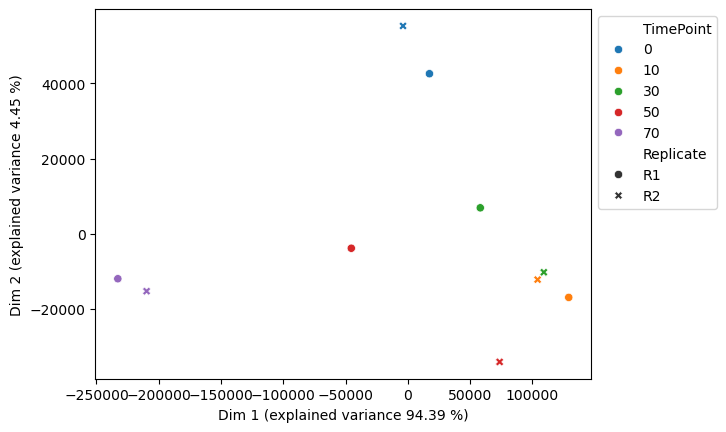

In [59]:
txPCA(tpms.iloc[:,0:tpms.shape[1]-2])

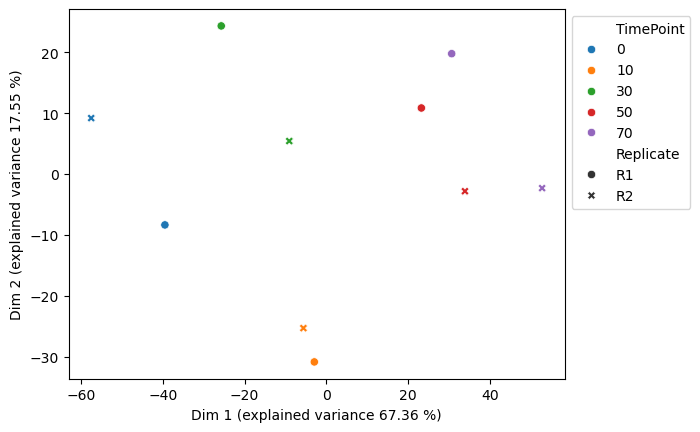

In [60]:
txPCA(logs.iloc[:,0:logs.shape[1]-2])

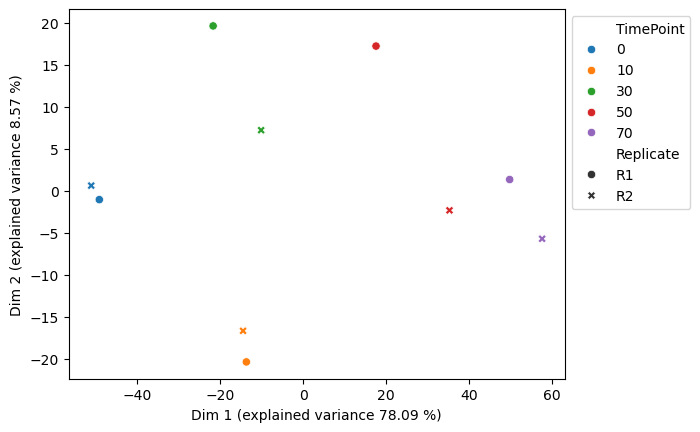

In [61]:
txPCA(logTPMs.iloc[:,0:logTPMs.shape[1]-2])

In [62]:
tpmHost = tpms[tpms['Entity'] == 'host']
tpmPhage = tpms[tpms['Entity'] == 'phage']
logTPMsHost = logTPMs[logTPMs['Entity'] == 'host']
logTPMsPhage = logTPMs[logTPMs['Entity'] == 'phage']

tpmHost

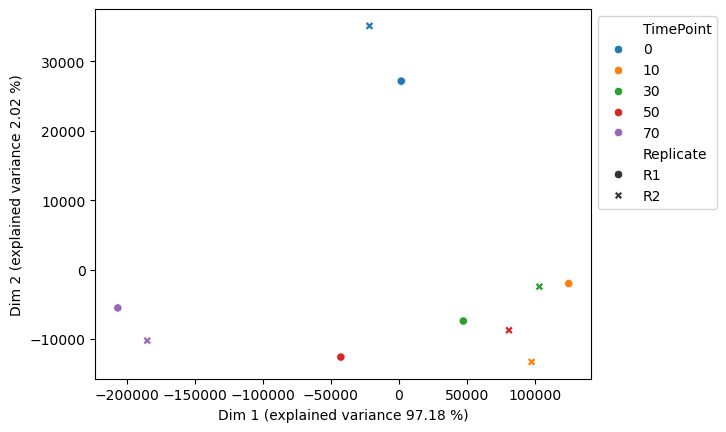

In [63]:
txPCA(tpmHost.iloc[:,0:tpmHost.shape[1]-2])

tpmPhage

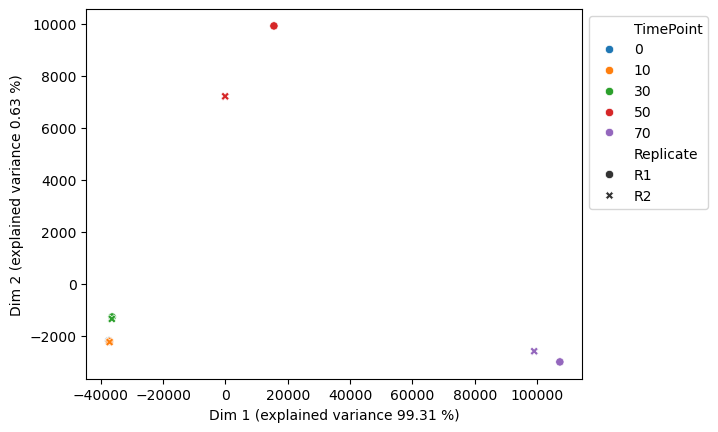

In [64]:
txPCA(tpmPhage.iloc[:,0:tpmPhage.shape[1]-2])

logTPM Host

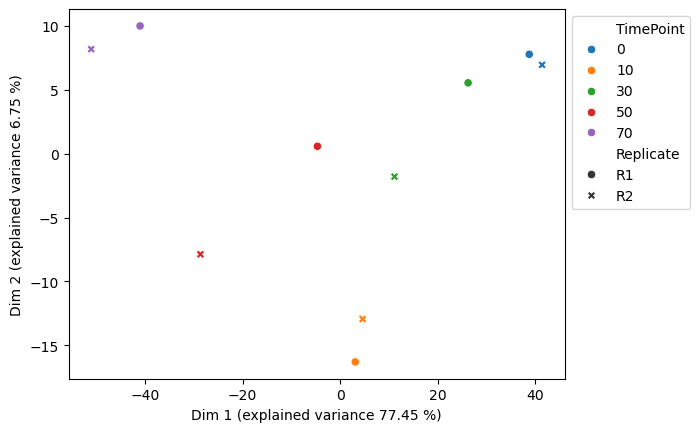

In [65]:
txPCA(logTPMsHost.iloc[:,0:logTPMsHost.shape[1]-2])

logTPM Phage

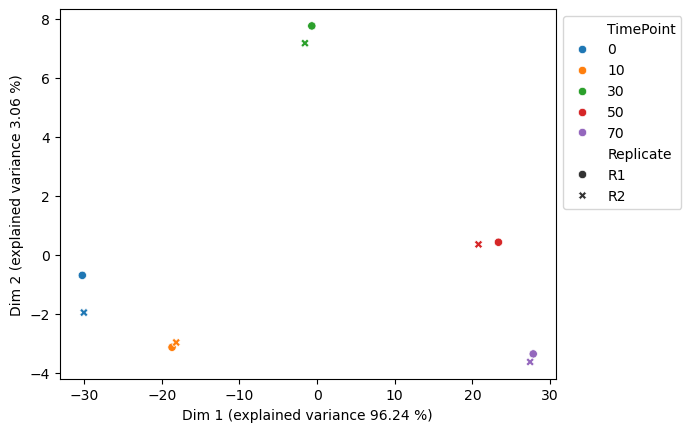

In [66]:
txPCA(logTPMsPhage.iloc[:,0:logTPMsPhage.shape[1]-2])

## 4. Final grouping

In [78]:
# Without rifampicin
TPMmeans, TPMsds = getMeanSD(tpms[['0_R1', '0_R2', '10_R1', '10_R2', '30_R1', '30_R2', '50_R1', '50_R2', '70_R1', '70_R2']])
TPMmeans[['Entity', 'Symbol']] = tpms[['Entity', 'Symbol']]
TPMmeans = TPMmeans[['0', '10', '30', '50', '70', 'Entity', 'Symbol']]
TPMsds[['Entity', 'Symbol']] = tpms[['Entity', 'Symbol']]
logTPM = logTPMs[['0_R1', '0_R2', '10_R1', '10_R2', '30_R1', '30_R2', '50_R1', '50_R2', '70_R1', '70_R2']]
logTPM[['Entity', 'Symbol']] = tpms[['Entity', 'Symbol']]
raw = df_norRNAs[['0_R1', '0_R2', '10_R1', '10_R2', '30_R1', '30_R2', '50_R1', '50_R2', '70_R1', '70_R2']]
raw[['Entity', 'Symbol']] = tpms[['Entity', 'Symbol']]

In [79]:
propExp = proportionalExp(TPMmeans[['0', '10', '30', '50', '70']])
propExp[['Entity', 'Symbol']] = TPMmeans[['Entity', 'Symbol']]
propExp

,0,10,30,50,70,Entity,Symbol
Geneid,,,,,,,
gene-HB27c_C1178,1.0,0.934830,0.539151,0.467020,0.343473,host,gene-HB27c_C1178
gene-HB27c_C0908,1.0,0.401852,0.575672,0.325515,0.318951,host,gene-HB27c_C0908
gene-HB27c_C1268,1.0,0.750563,0.775287,0.532339,0.304085,host,gene-HB27c_C1268
gene-HB27c_C1673,1.0,0.394540,0.701777,0.555031,0.606022,host,gene-HB27c_C1673
gene-HB27c_C1076,1.0,0.825722,0.933880,0.482530,0.287373,host,gene-HB27c_C1076
...,...,...,...,...,...,...,...
gene-HB27c_C0750,1.0,0.677086,0.736340,0.388725,0.290261,host,gene-HB27c_C0750
gene-HB27c_C1605,1.0,0.661366,0.789124,0.502571,0.438507,host,gene-HB27c_C1605
gene-HB27c_C1367,1.0,0.399893,0.911171,0.612948,0.729240,host,gene-HB27c_C1367


## 5. Phage gene classification

In [80]:
# Add a classification label based on exceeding 20 % of maximal expression

def classLabelThreshold(tpm):
    
    labels = list()
    
    i = 0
    while i < tpm.shape[0]:

        # Get array of expression values at time points
        expressions = list(tpm.iloc[i,0:(tpm.shape[1]-2)])

        # Get maximal value for each gene across time points
        maxTPM = max(expressions)

        # Get the threshold value
        thresHold = maxTPM*0.2

        # Subset expressions based on threshold
        filteredExpressions = [x for x in expressions if x >= thresHold]

        # Get index of time point
        indices = [expressions.index(x) for x in filteredExpressions]
        timePoint = min(indices)

        if timePoint == 0:
            labels.append('early')
        elif timePoint == 1:
            labels.append('early')
        elif timePoint == 2:
            labels.append('early')
        elif timePoint == 3:
            labels.append('middle')
        elif timePoint == 4:
            labels.append('late')

        i += 1

    tpmOut = tpm.copy()
    tpmOut['ClassThreshold'] = labels
    tpmOut.loc[tpmOut['Entity'] == 'host', 'ClassThreshold'] = 'None'

    return tpmOut

In [81]:
# Add a classification label based on maximal expression

def classLabelMax(tpm):
    
    labels = list()
    
    i = 0
    while i < tpm.shape[0]:

        # Get array of expression values at time points
        expressions = list(tpm.iloc[i,0:(tpm.shape[1]-3)])

        # Get maximal value for each gene across time points
        maxTPM = max(expressions)

        # Get the threshold value
        thresHold = maxTPM

        # Subset expressions based on threshold
        filteredExpressions = [x for x in expressions if x == thresHold]

        # Get index of time point
        indices = [expressions.index(x) for x in filteredExpressions]
        timePoint = min(indices)

        if timePoint == 0:
            labels.append('early')
        elif timePoint == 1:
            labels.append('early')
        elif timePoint == 2:
            labels.append('early')
        elif timePoint == 3:
            labels.append('middle')
        elif timePoint == 4:
            labels.append('late')

        i += 1

    tpmOut = tpm.copy()
    tpmOut['ClassMax'] = labels
    tpmOut.loc[tpmOut['Entity'] == 'host', 'ClassMax'] = 'None'

    return tpmOut

In [82]:
TPMmeans = classLabelThreshold(TPMmeans)

In [83]:
TPMmeans = classLabelMax(TPMmeans)

Add classes to other dfs.

In [84]:
TPMsds[['ClassThreshold', 'ClassMax']] = TPMmeans[['ClassThreshold', 'ClassMax']]
tpms[['ClassThreshold', 'ClassMax']] = TPMmeans[['ClassThreshold', 'ClassMax']]
logTPM[['ClassThreshold', 'ClassMax']] = TPMmeans[['ClassThreshold', 'ClassMax']]
propExp[['ClassThreshold', 'ClassMax']] = TPMmeans[['ClassThreshold', 'ClassMax']]
raw[['ClassThreshold', 'ClassMax']] = TPMmeans[['ClassThreshold', 'ClassMax']]

# gff3
gff3_final = gff3_genes.merge(TPMmeans[["ClassThreshold", "ClassMax"]], right_index=True, left_on="ID", how="left")
gff3_host  = gff3_final[gff3_final['seq_id'] != 'MH673671.2']
gff3_phage = gff3_final[gff3_final['seq_id'] == 'MH673671.2']
gff3_phage

,seq_id,source,type,start,end,phase,strand,score,ID,Name,gbkey,gene_biotype,locus_tag,gene,product,annot,PHROG,category,ClassThreshold,ClassMax
2322,MH673671.2,Genbank,gene,85,618,.,+,.,gene-phiKo_26,phiKo_26,Gene,protein_coding,phiKo_26,gene-phiKo_26,hypothetical protein,hypothetical protein,No_PHROG,unknown function,early,middle
2323,MH673671.2,Genbank,gene,615,902,.,+,.,gene-phiKo_25,phiKo_25,Gene,protein_coding,phiKo_25,gene-phiKo_25,hypothetical protein,hypothetical protein,No_PHROG,unknown function,early,middle
2324,MH673671.2,Genbank,gene,908,1102,.,+,.,gene-phiKo_24,phiKo_24,Gene,protein_coding,phiKo_24,gene-phiKo_24,hypothetical protein,hypothetical protein,No_PHROG,unknown function,early,middle
2325,MH673671.2,Genbank,gene,1113,1496,.,+,.,gene-phiKo_23,phiKo_23,Gene,protein_coding,phiKo_23,gene-phiKo_23,hypothetical protein,hypothetical protein,No_PHROG,unknown function,early,middle
2326,MH673671.2,Genbank,gene,1557,1775,.,+,.,gene-phiKo_22,phiKo_22,Gene,protein_coding,phiKo_22,gene-phiKo_22,hypothetical protein,hypothetical protein,No_PHROG,unknown function,middle,middle
2327,MH673671.2,Genbank,gene,1784,2731,.,+,.,gene-phiKo_21,phiKo_21,Gene,protein_coding,phiKo_21,gene-phiKo_21,hypothetical protein,hypothetical protein,No_PHROG,unknown function,middle,late
2328,MH673671.2,Genbank,gene,2728,3243,.,+,.,gene-phiKo_20,phiKo_20,Gene,protein_coding,phiKo_20,gene-phiKo_20,lysozyme,amidase,822,lysis,middle,late
2329,MH673671.2,Genbank,gene,3259,3507,.,+,.,gene-phiKo_19,phiKo_19,Gene,protein_coding,phiKo_19,gene-phiKo_19,head morphogenesis protein,hypothetical protein,No_PHROG,unknown function,middle,late
2330,MH673671.2,Genbank,gene,3510,3731,.,+,.,gene-phiKo_18,phiKo_18,Gene,protein_coding,phiKo_18,gene-phiKo_18,hypothetical protein,hypothetical protein,No_PHROG,unknown function,middle,late
2331,MH673671.2,Genbank,gene,3736,3921,.,+,.,gene-phiKo_17,phiKo_17,Gene,protein_coding,phiKo_17,gene-phiKo_17,ribonuclease Z,hypothetical protein,No_PHROG,unknown function,middle,late


In [86]:
propExp.loc[propExp['Entity'] == 'phage']

,0,10,30,50,70,Entity,Symbol,ClassThreshold,ClassMax
Geneid,,,,,,,,,
gene-phiKo_12,0.000166,0.001696,0.005900,0.294706,1.000000,phage,gene-phiKo_12,middle,late
gene-phiKo_16,0.000215,0.001582,0.015351,0.481578,1.000000,phage,gene-phiKo_16,middle,late
gene-phiKo_13,0.000129,0.000751,0.006739,0.330300,1.000000,phage,gene-phiKo_13,middle,late
gene-phiKo_06,0.000232,0.001870,0.006049,0.260558,1.000000,phage,gene-phiKo_06,middle,late
gene-phiKo_02,0.000195,0.000906,0.008004,0.435893,1.000000,phage,gene-phiKo_02,middle,late
gene-phiKo_14,0.000159,0.001140,0.009153,0.440109,1.000000,phage,gene-phiKo_14,middle,late
gene-phiKo_15,0.000371,0.001871,0.014286,0.455339,1.000000,phage,gene-phiKo_15,middle,late
gene-phiKo_17,0.000164,0.001452,0.014901,0.479400,1.000000,phage,gene-phiKo_17,middle,late
gene-phiKo_03,0.000141,0.000698,0.009019,0.418944,1.000000,phage,gene-phiKo_03,middle,late


## 6. Add variance to all dataframes

Base variance call on tpms.

In [87]:
def stabilizedVariance(df):
    labels = list()
    
    i = 0
    while i < df.shape[0]:

        # Get array of expression values at time points
        expressions = list(df.iloc[i,0:(df.shape[1]-4)])

        # Get mean expression for the gene
        exprMean = np.mean(np.array(expressions))

        # Get the variance for the gene
        varGene = np.var(np.array(expressions))

        # Stabilized variance
        stableVarGene = varGene/exprMean

        labels.append(stableVarGene)

        i += 1

    tpmOut = df.copy()
    tpmOut['Variance'] = labels

    return tpmOut

In [88]:
tpms = stabilizedVariance(tpms)
tpms

SampleNames,0_R1,0_R2,10_R1,10_R2,30_R1,30_R2,50_R1,50_R2,70_R1,70_R2,Entity,Symbol,ClassThreshold,ClassMax,Variance
Geneid,,,,,,,,,,,,,,,
gene-HB27c_C1178,41.883930,56.571848,51.308618,40.730796,42.583871,10.498690,18.854973,27.125805,22.859796,10.957113,host,gene-HB27c_C1178,None,None,7.565814
gene-HB27c_C0908,151.121747,134.229566,56.875305,57.793697,91.581990,72.686878,63.546356,29.339857,47.682704,43.330401,host,gene-HB27c_C0908,None,None,18.942340
gene-HB27c_C1268,96.018749,98.805020,68.945043,77.282476,80.951186,70.093093,62.801788,40.910533,33.895014,25.347953,host,gene-HB27c_C1268,None,None,8.662126
gene-HB27c_C1673,101.219497,91.972110,36.945695,39.276125,76.376472,59.200948,66.396442,40.830795,60.336166,56.742192,host,gene-HB27c_C1673,None,None,6.808144
gene-HB27c_C1076,58.710661,76.981731,50.681263,61.362990,72.209800,54.510667,38.681513,26.794136,20.451129,18.543141,host,gene-HB27c_C1076,None,None,8.209968
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
gene-HB27c_C0750,148.849043,172.089187,101.376807,115.926112,126.505256,109.814505,76.831599,47.925038,38.492946,54.662968,host,gene-HB27c_C0750,None,None,17.853319
gene-HB27c_C1605,116.963102,99.482196,65.804472,77.345182,94.686685,76.115504,61.078079,47.701017,47.433684,47.479057,host,gene-HB27c_C1605,None,None,7.179225
gene-HB27c_C1367,1077.147649,1077.134551,397.030369,464.451168,1219.095049,743.824896,819.250912,501.212898,847.254650,723.734810,host,gene-HB27c_C1367,None,None,89.375255


In [89]:
logTPM['Variance'] = tpms['Variance']
TPMmeans['Variance'] = tpms['Variance']
TPMsds['Variance'] = tpms['Variance']
propExp['Variance'] = tpms['Variance']
raw['Variance'] = tpms['Variance']

In [90]:
propExp

,0,10,30,50,70,Entity,Symbol,ClassThreshold,ClassMax,Variance
Geneid,,,,,,,,,,
gene-HB27c_C1178,1.0,0.934830,0.539151,0.467020,0.343473,host,gene-HB27c_C1178,None,None,7.565814
gene-HB27c_C0908,1.0,0.401852,0.575672,0.325515,0.318951,host,gene-HB27c_C0908,None,None,18.942340
gene-HB27c_C1268,1.0,0.750563,0.775287,0.532339,0.304085,host,gene-HB27c_C1268,None,None,8.662126
gene-HB27c_C1673,1.0,0.394540,0.701777,0.555031,0.606022,host,gene-HB27c_C1673,None,None,6.808144
gene-HB27c_C1076,1.0,0.825722,0.933880,0.482530,0.287373,host,gene-HB27c_C1076,None,None,8.209968
...,...,...,...,...,...,...,...,...,...,...
gene-HB27c_C0750,1.0,0.677086,0.736340,0.388725,0.290261,host,gene-HB27c_C0750,None,None,17.853319
gene-HB27c_C1605,1.0,0.661366,0.789124,0.502571,0.438507,host,gene-HB27c_C1605,None,None,7.179225
gene-HB27c_C1367,1.0,0.399893,0.911171,0.612948,0.729240,host,gene-HB27c_C1367,None,None,89.375255


## 7. Write data to output

In [91]:
# Full TPM table
tpms.to_csv('Artamonova_2020_full_TPM.tsv', sep = '\t')
# Full raw_counts table
raw.to_csv('Artamonova_2020_full_raw_counts.tsv', sep = '\t')
# Summarized (time point means) TPM table
TPMmeans.to_csv('Artamonova_2020_TPM_means.tsv', sep = '\t')
# Summarized (time point) TPM standard deviation
TPMsds.to_csv('Artamonova_2020_TPM_std.tsv', sep = '\t')
# Proportional expression per gene and time point
propExp.to_csv('Artamonova_2020_fractional_expresssion.tsv', sep = '\t')
# Processed gff3 file
gff3_host.to_csv('Artamonova_2020_host_gff3.tsv', sep='\t')
gff3_phage.to_csv('Artamonova_2020_phage_gff3.tsv', sep='\t')